In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
nltk.download('stopwords')
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import SMOTE
import joblib, os

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manid\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Using TensorFlow backend.


In [2]:
df=pd.read_csv('ChatGPT_Reviews.csv')
df

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,8/23/2024 19:30
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,8/23/2024 19:28
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,8/23/2024 19:22
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,8/23/2024 19:20
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,8/23/2024 19:20
...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,7/27/2023 16:26
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,9/23/2023 16:25
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,11/8/2023 13:57
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,7/25/2023 15:32


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [4]:
df['Review'].fillna('No Review',inplace=True)

In [5]:
def preprocess_text(text):
    text = text.lower()  
    text = re.sub(r'\d+', '', text)  
    text = re.sub(r'[^\w\s]', '', text)  
    text = re.sub(r'\s+', ' ', text)  
    stop_words = set(stopwords.words('english'))
    text = " ".join([word for word in text.split() if word not in stop_words])  
    return text

df['Cleaned Review'] = df['Review'].apply(preprocess_text)
df

,Review Id,Review,Ratings,Review Date,Cleaned Review
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,8/23/2024 19:30,good
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,8/23/2024 19:28,good
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,8/23/2024 19:22,nice app
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,8/23/2024 19:20,nice ig
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,8/23/2024 19:20,great app bot accurate anything gives tips gam...
...,...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,7/27/2023 16:26,update
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,9/23/2023 16:25,grear
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,11/8/2023 13:57,funtastic app
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,7/25/2023 15:32,hi


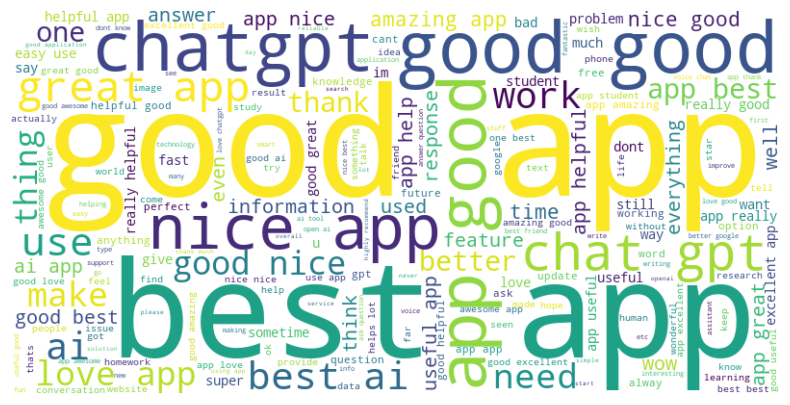

In [6]:
def word_cloud(df):
    text = " ".join(review for review in df['Cleaned Review'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

word_cloud(df)

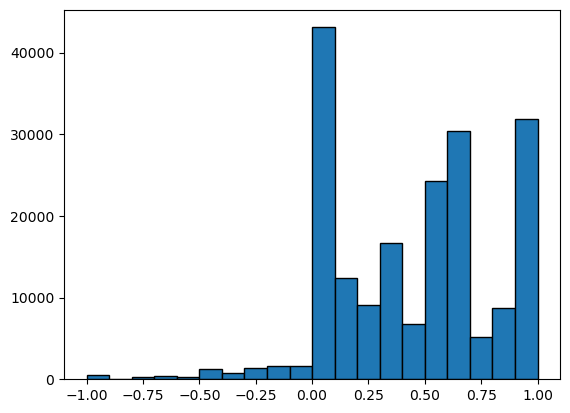

In [7]:
def analyze_sentiments(df):
    def analyze_sentiment(text):
        analysis = TextBlob(text)
        return analysis.polarity
    df['Sentiment'] = df['Review'].apply(analyze_sentiment)
    plt.hist(df['Sentiment'], bins=20, edgecolor='black')
    plt.show()
        
analyze_sentiments(df)

In [8]:
df

,Review Id,Review,Ratings,Review Date,Cleaned Review,Sentiment
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,8/23/2024 19:30,good,0.7000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,8/23/2024 19:28,good,0.7000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,8/23/2024 19:22,nice app,0.6000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,8/23/2024 19:20,nice ig,0.6000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,8/23/2024 19:20,great app bot accurate anything gives tips gam...,0.4125
...,...,...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,7/27/2023 16:26,update,0.0000
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,9/23/2023 16:25,grear,0.0000
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,11/8/2023 13:57,funtastic app,0.0000
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,7/25/2023 15:32,hi,0.0000


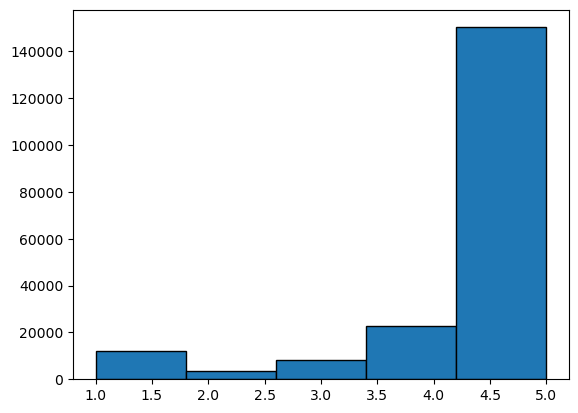

In [9]:
plt.hist(df['Ratings'], bins=5, edgecolor='black')
plt.show()

In [10]:
df

,Review Id,Review,Ratings,Review Date,Cleaned Review,Sentiment
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,8/23/2024 19:30,good,0.7000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,8/23/2024 19:28,good,0.7000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,8/23/2024 19:22,nice app,0.6000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,8/23/2024 19:20,nice ig,0.6000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,8/23/2024 19:20,great app bot accurate anything gives tips gam...,0.4125
...,...,...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,7/27/2023 16:26,update,0.0000
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,9/23/2023 16:25,grear,0.0000
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,11/8/2023 13:57,funtastic app,0.0000
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,7/25/2023 15:32,hi,0.0000


In [11]:
def sentiment_categorizer(polarity):
    if polarity>0.25:
        return "Positive"
    elif polarity<-0.25:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Sentiment'].apply(sentiment_categorizer)

In [12]:
df.drop(columns=['Review Id','Review','Review Date'],inplace=True)
object_columns = df.select_dtypes(['object']).columns
df[object_columns] = df[object_columns].astype('category')

In [13]:
label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}  

In [14]:
df1 = df

In [15]:
y = df['Sentiment'].map(label_mapping)

X = df.drop(columns=['Sentiment'])

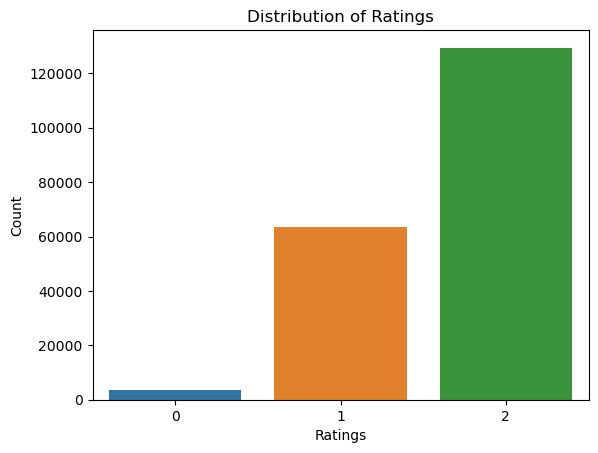

In [16]:
sns.countplot(x=y)
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [17]:
X

,Ratings,Cleaned Review
0,5,good
1,5,good
2,5,nice app
3,5,nice ig
4,5,great app bot accurate anything gives tips gam...
...,...,...
196722,5,update
196723,5,grear
196724,5,funtastic app
196725,5,hi


In [18]:
y

0         2
1         2
2         2
3         2
4         2
         ..
196722    1
196723    1
196724    1
196725    1
196726    1
Name: Sentiment, Length: 196727, dtype: category
Categories (3, int64): [0, 1, 2]

In [19]:
# Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X['Cleaned Review'])
X

<196727x47306 sparse matrix of type '<class 'numpy.float64'>'
	with 907497 stored elements in Compressed Sparse Row format>

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
smote = SMOTE(random_state=42)
X_train, y_train= smote.fit_resample(X_train, y_train)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((310803, 47306), (39346, 47306), (310803,), (39346,))

In [23]:
labels=['Negative','Neutral','Positive']
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [24]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, testY,predict):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

Model loaded successfully.
DecisionTreeClassifier Accuracy    : 57.8229044883851
DecisionTreeClassifier Precision   : 55.32926078370104
DecisionTreeClassifier Recall      : 62.3663950026634
DecisionTreeClassifier FSCORE      : 50.83270413720506

 DecisionTreeClassifier classification report
               precision    recall  f1-score   support

    Negative       0.46      0.30      0.36       712
     Neutral       0.44      0.97      0.60     12810
    Positive       0.97      0.39      0.56     25824

    accuracy                           0.58     39346
   macro avg       0.62      0.55      0.51     39346
weighted avg       0.79      0.58      0.57     39346



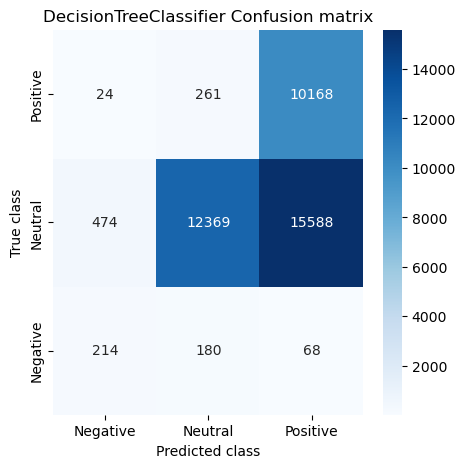

In [25]:
if os.path.exists('model/DecisionTreeClassifier.pkl'):
    # Load the trained model from the file
    DTC = joblib.load('model/DecisionTreeClassifier.pkl')
    print("Model loaded successfully.")
    predict = DTC.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)
else:
    # Train the model (assuming X_train and y_train are defined)
    DTC = DecisionTreeClassifier(max_depth=4)
    DTC.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(DTC, 'model/DecisionTreeClassifier.pkl')
    print("Model saved successfully.")
    predict = DTC.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)


Model loaded successfully.
XGBClassifier Accuracy    : 91.24434504142734
XGBClassifier Precision   : 87.29877257809697
XGBClassifier Recall      : 79.1983772613635
XGBClassifier FSCORE      : 82.56212454738477

 XGBClassifier classification report
               precision    recall  f1-score   support

    Negative       0.57      0.79      0.66       712
     Neutral       0.84      0.90      0.87     12810
    Positive       0.96      0.92      0.94     25824

    accuracy                           0.91     39346
   macro avg       0.79      0.87      0.83     39346
weighted avg       0.92      0.91      0.91     39346



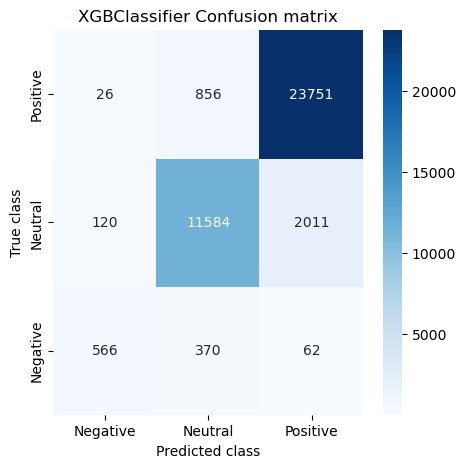

In [26]:
if os.path.exists('model/XGB.pkl'):
    XGB = joblib.load('model/XGB.pkl')
    print("Model loaded successfully.")
    predict = XGB.predict(X_test)
    calculateMetrics("XGBClassifier", predict, y_test)
else:
    XGB = XGBClassifier()
    DTC.fit(X_train, y_train)
    joblib.dump(XGB, 'model/XGB.pkl')
    print("Model saved successfully.")
    predict = XGB.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)


In [27]:
def predict_sentiment(review_text, model_path = 'model/XGB.pkl', vectorizer=vectorizer):
    # Preprocess the text
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        stop_words = set(stopwords.words('english'))
        text = " ".join([word for word in text.split() if word not in stop_words])
        return text

    cleaned_text = preprocess_text(review_text)
    
    # Vectorize the cleaned text
    X_vect = vectorizer.transform([cleaned_text])

    # Load the model
    if os.path.exists(model_path):
        model = joblib.load(model_path)
    else:
        print("Model file not found.")
        return None

    # Predict the sentiment label
    predicted_label = model.predict(X_vect)[0]

    # Map label back to sentiment category
    inverse_label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    predicted_sentiment = inverse_label_mapping[predicted_label]

    return predicted_sentiment


In [28]:
sample_review = "ChatGPT provides very helpful and insightful answers!"
sentiment = predict_sentiment(sample_review, 'model/DecisionTreeClassifier.pkl')
print(f"Predicted Sentiment (Decision Tree): {sentiment}")

Predicted Sentiment (Decision Tree): Neutral


In [33]:
sample_review = input("Enter a review: ")
sentiment = predict_sentiment(sample_review, 'model/XGB.pkl')
print(f"Predicted Sentiment (XGBoost): {sentiment}")

Enter a review: not bad
Predicted Sentiment (XGBoost): Negative
